# Metrics + Data Viz for Qwen/Gemma NER & LID

In [1]:
#Necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [22]:
DATASET = "data/outputs/qwen_ner_2026-05-18_13-16-15.csv" #to replace
df = pd.read_csv(DATASET)

In [23]:
df.head()

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,qwen_ner
0,0,post_0001,1,0,yabancı,TR,NaN,NaN,O
1,1,post_0001,1,1,bir,TR,NaN,NaN,O
2,2,post_0001,1,2,hocamızın,TR,NaN,NaN,O
3,3,post_0001,1,3,yarı,TR,NaN,NaN,O
4,4,post_0001,1,4,şaka,TR,NaN,NaN,O


## Qwen LID Results

Qwen LID labels vs human-annotated LID labels. 

Prompt as follows:

Identify the language of the following token as Turkish, English, mixed Tur-Eng, or other.
Reply with either "TR" for Turkish, "EN" for English, "MIXED" for mixed, or "OTHER" for other.


In [113]:
#Remove rows with human-annotated "Other" aka non-language token/named entity rows
df = df[df['lid'] != 'OTHER']

In [25]:
#Sanity check
df["qwen_ner"].value_counts()

qwen_ner
O          4457
B-PROD      105
I-PROD       49
B-ORG        49
B-TITLE      40
I-TITLE      35
B-TIME       21
B-PER        18
I-ORG        16
B-OTHER      15
B-LOC        14
I-PER        12
B-GROUP       6
I-TIME        3
I-OTHER       2
B-EVENT       2
I-GROUP       2
I-LOC         1
I-EVENT       1
Name: count, dtype: int64

In [8]:
def clean_preds(token):
    if "TR" in token:
        return "TR"
    if "EN" in token:
        return "EN"
    if "NE" in token:
        return "NE"
    if "AMBIGUOUS" in token:
        return "AMBIGUOUS"
    if "OTHER" in token:
        return "OTHER"
    return token

df["gemma_langid"] = df["gemma_langid"].apply(clean_preds)
df["gemma_langid"].value_counts()

gemma_langid
TR           3560
EN            801
OTHER         161
NE            144
MIXED         124
AMBIGUOUS      58
Name: count, dtype: int64

In [115]:
df = df[(df['qwen_langid'] == 'OTHER') | (df['qwen_langid'] == 'TR') | (df['qwen_langid'] == 'MIXED') | (df['qwen_langid'] == 'EN')]

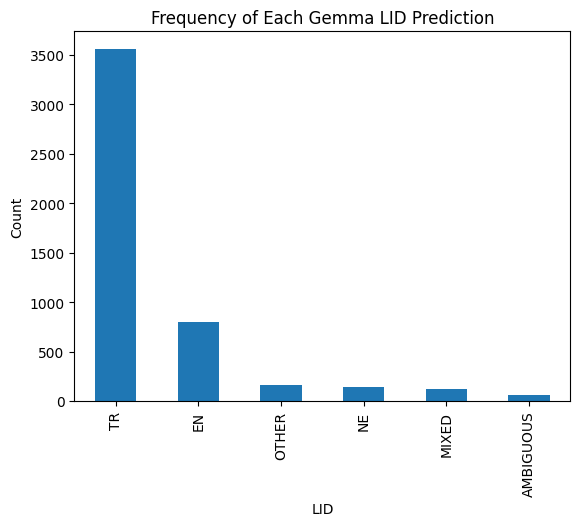

In [9]:
#Frequency of predictions
df['gemma_langid'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Gemma LID Prediction')
plt.xlabel('LID')
plt.ylabel('Count')
plt.show()

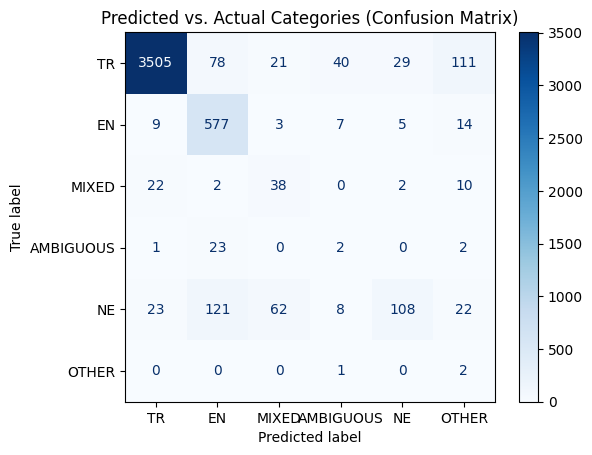

In [10]:
#Confusion matrix
cm = confusion_matrix(df['lid'], df['gemma_langid'], labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [11]:
#Macro F1
macro_f1 = f1_score(df["lid"], df["gemma_langid"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.4445



In [12]:
#F1 Per Class
f1_per_class = f1_score(df["lid"], df["gemma_langid"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.04651163 0.81497175 0.38383838 0.44262295 0.02439024 0.9545207 ]



In [13]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["lid"], df["gemma_langid"]))

Classification Report:
              precision    recall  f1-score   support

   AMBIGUOUS       0.03      0.07      0.05        28
          EN       0.72      0.94      0.81       615
       MIXED       0.31      0.51      0.38        74
          NE       0.75      0.31      0.44       344
       OTHER       0.01      0.67      0.02         3
          TR       0.98      0.93      0.95      3784

    accuracy                           0.87      4848
   macro avg       0.47      0.57      0.44      4848
weighted avg       0.92      0.87      0.89      4848



In [14]:
mismatched_rows = df[df['lid'] != df['gemma_langid']]

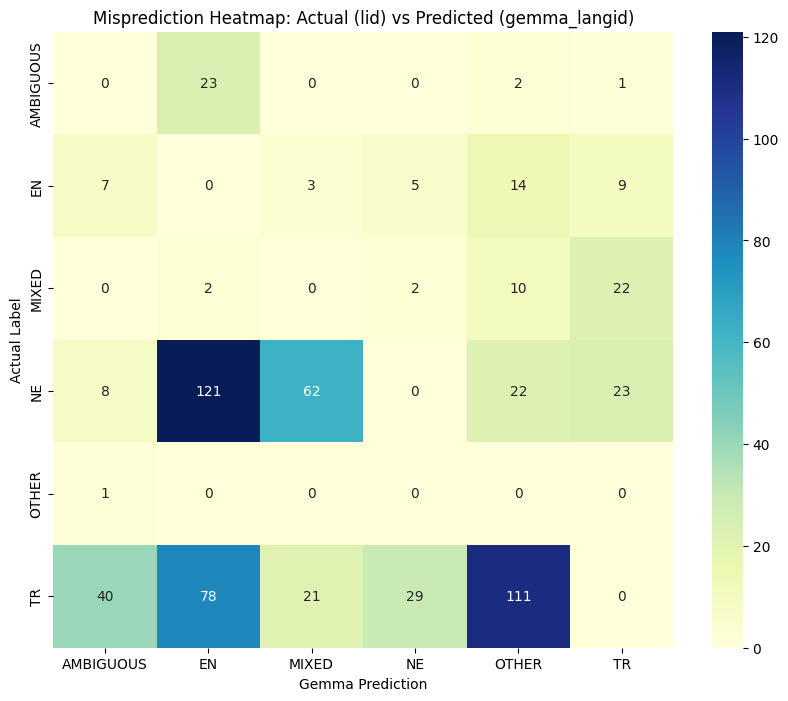

In [15]:
#Mismatched rows CM
cm = pd.crosstab(mismatched_rows['lid'], mismatched_rows['gemma_langid'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (lid) vs Predicted (gemma_langid)')
plt.ylabel('Actual Label')
plt.xlabel('Gemma Prediction')
plt.show()

In [16]:
mismatched_rows[mismatched_rows["lid"] == "MIXED"]

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gemma_langid
190,190,post_0008,1,2,group'un,MIXED,MIXED,NaN,TR
389,389,post_0016,1,5,conlarindan,MIXED,MIXED,NaN,TR
464,464,post_0019,4,0,lgbti,MIXED,MIXED,NaN,OTHER
570,570,post_0022,3,17,djim,MIXED,MIXED,NaN,OTHER
584,584,post_0022,4,10,djlik,MIXED,MIXED,NaN,TR
670,670,post_0027,4,3,mottom,MIXED,MIXED,NaN,OTHER
843,843,post_0031,1,4,veganlar,MIXED,MIXED,NaN,TR
995,995,post_0036,1,3,downloadla,MIXED,MIXED,NaN,TR
1075,1075,post_0039,4,2,historylerini,MIXED,MIXED,NaN,TR
1174,1174,post_002,1,42,toollar,MIXED,MIXED,O,OTHER


## Qwen NER Results

In [26]:
DATASET = "data/outputs/qwen_ner_2026-05-18_13-16-15.csv" #to replace
df = pd.read_csv(DATASET)

In [27]:
#Sanity check
df["qwen_ner"].value_counts()

qwen_ner
O          4457
B-PROD      105
I-PROD       49
B-ORG        49
B-TITLE      40
I-TITLE      35
B-TIME       21
B-PER        18
I-ORG        16
B-OTHER      15
B-LOC        14
I-PER        12
B-GROUP       6
I-TIME        3
I-OTHER       2
B-EVENT       2
I-GROUP       2
I-LOC         1
I-EVENT       1
Name: count, dtype: int64

In [126]:
df = df[(df["qwen_ner"] == "O (no label)") | (df["qwen_ner"] == "B-PER") | (df["qwen_ner"] == "I-PER") | (df["qwen_ner"] == "B-ORG") | (df["qwen_ner"] == "I-ORG") | (df["qwen_ner"] == "B-MISC") |  (df["qwen_ner"] == "I-MISC") | (df["qwen_ner"] == "B-LOC") | (df["qwen_ner"] == "I-LOC")]

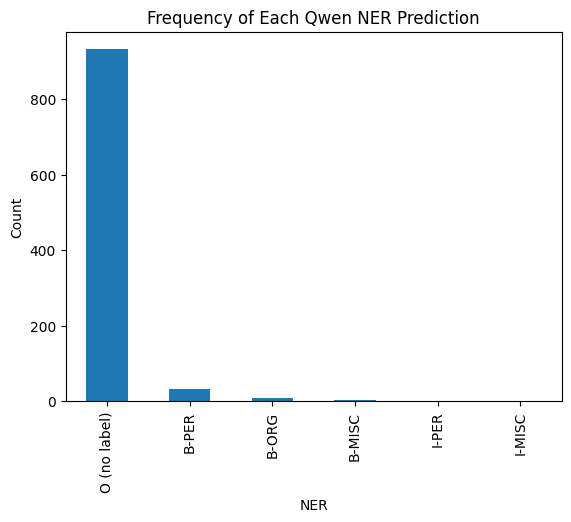

In [127]:
#Frequency of predictions
df['qwen_ner'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Qwen NER Prediction')
plt.xlabel('NER')
plt.ylabel('Count')
plt.show()

In [32]:
df.isna().sum()

Unnamed: 0            0
doc_id                0
sent_id               0
tok_id                0
token                 0
lid                   0
borrowed_suffix    4706
ner                   0
qwen_ner              0
dtype: int64

In [31]:
df["ner"] = df["ner"].fillna("O")

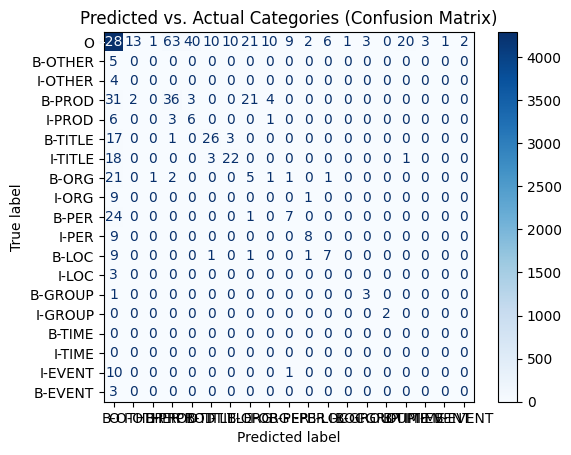

In [33]:
#Confusion matrix
cm = confusion_matrix(df['ner'], df['qwen_ner'], labels=["O", "B-OTHER", "I-OTHER", "B-PROD",
"I-PROD", "B-TITLE", "I-TITLE", "B-ORG", "I-ORG", "B-PER", "I-PER", 
"B-LOC", "I-LOC","B-GROUP", "I-GROUP",
"B-TIME", "I-TIME", "I-EVENT",
"B-EVENT"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["O", "B-OTHER", "I-OTHER", "B-PROD",
"I-PROD", "B-TITLE", "I-TITLE", "B-ORG", "I-ORG", "B-PER", "I-PER", 
"B-LOC", "I-LOC","B-GROUP", "I-GROUP",
"B-TIME", "I-TIME", "I-EVENT",
"B-EVENT"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [34]:
#Macro F1
macro_f1 = f1_score(df["ner"], df["qwen_ner"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.2964



In [35]:
#F1 Per Class
f1_per_class = f1_score(df["ner"], df["qwen_ner"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.         0.6        0.42424242 0.12345679 0.         0.28
 0.35643564 0.         0.59770115 0.         1.         0.
 0.         0.         0.55172414 0.18461538 0.         0.55696203
 0.95702645]



In [36]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["ner"], df["qwen_ner"]))

Classification Report:
              precision    recall  f1-score   support

     B-EVENT       0.00      0.00      0.00         3
     B-GROUP       0.50      0.75      0.60         4
       B-LOC       0.50      0.37      0.42        19
       B-ORG       0.10      0.16      0.12        32
     B-OTHER       0.00      0.00      0.00         5
       B-PER       0.39      0.22      0.28        32
      B-PROD       0.34      0.37      0.36        97
      B-TIME       0.00      0.00      0.00         0
     B-TITLE       0.65      0.55      0.60        47
     I-EVENT       0.00      0.00      0.00        11
     I-GROUP       1.00      1.00      1.00         2
       I-LOC       0.00      0.00      0.00         3
       I-ORG       0.00      0.00      0.00        10
     I-OTHER       0.00      0.00      0.00         4
       I-PER       0.67      0.47      0.55        17
      I-PROD       0.12      0.38      0.18        16
      I-TIME       0.00      0.00      0.00         0
    

/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [132]:
mismatched_rows = df[df['ner'] != df['qwen_ner']]

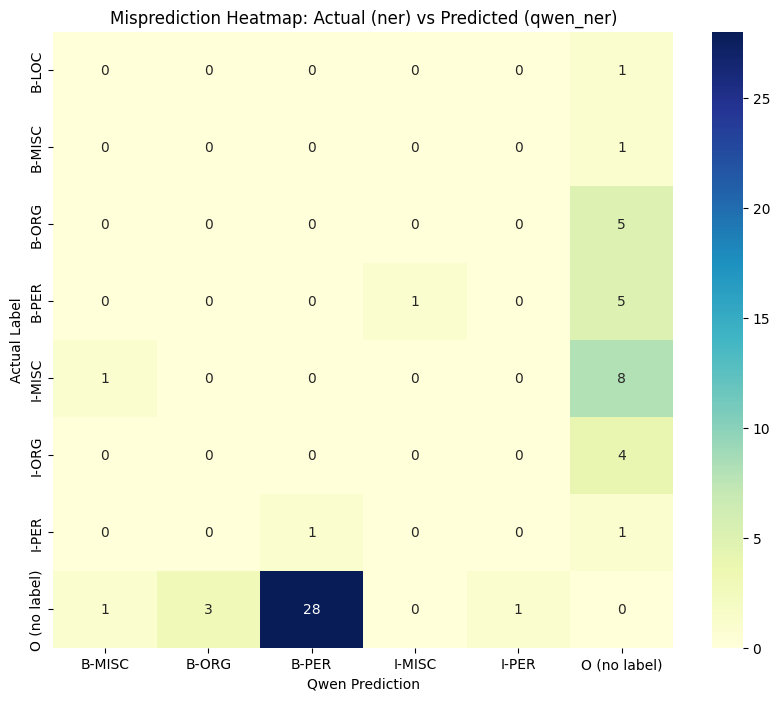

In [133]:
#Mismatched rows CM
cm = pd.crosstab(mismatched_rows['ner'], mismatched_rows['qwen_ner'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (ner) vs Predicted (qwen_ner)')
plt.ylabel('Actual Label')
plt.xlabel('Qwen Prediction')
plt.show()

In [134]:
mismatched_rows

,Unnamed: 0.1,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,qwen_ner
32,32,32,post_0001,2,12,yola,TR,NONE,O (no label),B-PER
88,88,88,post_0003,3,7,oyle,TR,NONE,O (no label),B-PER
106,106,106,post_0004,1,2,türkçe,TR,NONE,O (no label),B-MISC
135,135,135,post_0004,2,29,gibi,TR,NONE,O (no label),B-PER
160,160,160,post_0005,2,0,google,OTHER,NONE,O (no label),B-ORG
...,...,...,...,...,...,...,...,...,...,...
1021,1021,1021,post_0036,4,0,fm,EN,NONE,I-ORG,O (no label)
1025,1025,1025,post_0036,5,2,tam,TR,NONE,O (no label),B-PER
1054,1054,1054,post_0038,1,5,diyerek,TR,NONE,O (no label),B-PER
1088,1088,1088,post_0039,5,3,james,OTHER,NONE,I-PER,B-PER


## Gemma LID Results

Gemma LID labels vs human-annotated LID labels. 

Prompt as follows:

Identify the language of the following token as Turkish, English, mixed Tur-Eng, or other.
Reply with either "TR" for Turkish, "EN" for English, "MIXED" for mixed, or "OTHER" for other.


In [135]:
DATASET = "data/outputs/gemma_lid_2026-02-20_01-18-43.csv" #to replace with gemma table
df = pd.read_csv(DATASET)

In [136]:
#Remove rows with human-annotated "Other" aka non-language token/named entity rows
df = df[df['lid'] != 'OTHER']

In [137]:
#Sanity check
df["gemma_langid"].value_counts()

gemma_langid
\nTR \n                                                                             598
\nEN \n                                                                             139
\n\nTR \n                                                                            72
TR \n                                                                                63
\n\nEN \n                                                                            32
                                                                                   ... 
答TR                                                                                   1
<TR> \n                                                                               1
Please provide the token! I need to see the text to identify the language. 😊  \n      1
. EN \n                                                                               1
**EN** \n                                                                             1
Name: count, Length

In [139]:
df = df[(df["gemma_langid"] == "EN") | (df["gemma_langid"] == "TR") | (df["gemma_langid"] == "MIXED") | (df["gemma_langid"] == "OTHER")]

In [140]:
df['gemma_langid'].value_counts()

gemma_langid
TR       801
EN       190
OTHER     42
MIXED     25
Name: count, dtype: int64

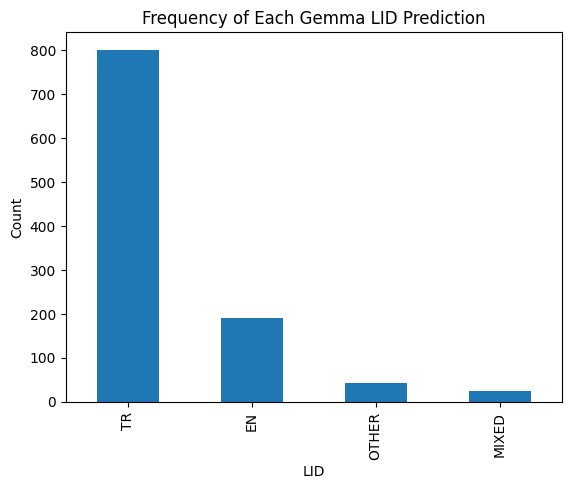

In [141]:
#Frequency of predictions
df['gemma_langid'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Gemma LID Prediction')
plt.xlabel('LID')
plt.ylabel('Count')
plt.show()

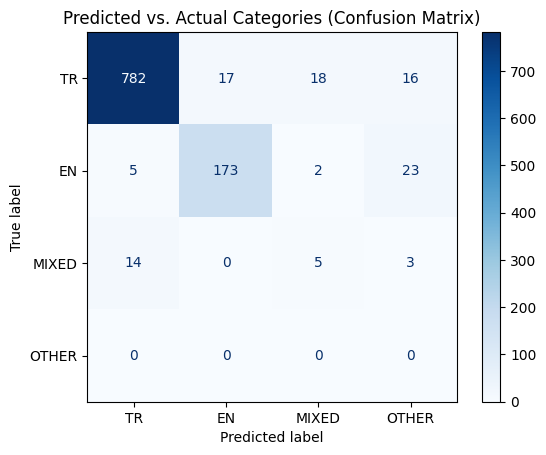

In [142]:
#Confusion matrix
cm = confusion_matrix(df['lid'], df['gemma_langid'], labels=["TR", "EN", "MIXED", "OTHER"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TR", "EN", "MIXED", "OTHER"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [143]:
#Macro F1
macro_f1 = f1_score(df["lid"], df["gemma_langid"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.5126



In [144]:
#F1 Per Class
f1_per_class = f1_score(df["lid"], df["gemma_langid"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.88040712 0.21276596 0.         0.95716034]



In [145]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["lid"], df["gemma_langid"]))

Classification Report:
              precision    recall  f1-score   support

          EN       0.91      0.85      0.88       203
       MIXED       0.20      0.23      0.21        22
       OTHER       0.00      0.00      0.00         0
          TR       0.98      0.94      0.96       833

    accuracy                           0.91      1058
   macro avg       0.52      0.50      0.51      1058
weighted avg       0.95      0.91      0.93      1058



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [146]:
mismatched_rows = df[df['lid'] != df['gemma_langid']]

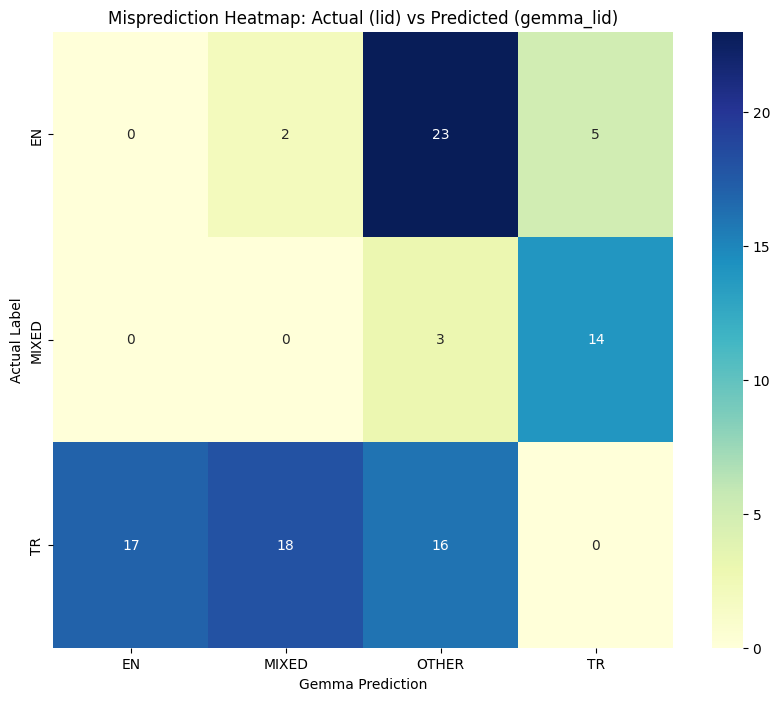

In [147]:
#Mismatched rows CM
cm = pd.crosstab(mismatched_rows['lid'], mismatched_rows['gemma_langid'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (lid) vs Predicted (gemma_lid)')
plt.ylabel('Actual Label')
plt.xlabel('Gemma Prediction')
plt.show()

## Gemma NER Results

In [148]:
DATASET = "data/outputs/gemma_ner_2026-02-20_09-51-43.csv" #to replace
df = pd.read_csv(DATASET)

In [149]:
#Sanity check
df["gemma_ner"].value_counts()

gemma_ner
\nO (no label) \n                                                                                                                                                                                                      620
\n\nO (no label) \n                                                                                                                                                                                                    177
\nB-MISC \n                                                                                                                                                                                                             50
\nB-PER \n                                                                                                                                                                                                              35
\nO \n                                                                                                            

In [150]:
print(df['gemma_ner'].value_counts().to_string())

gemma_ner
\nO (no label) \n                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

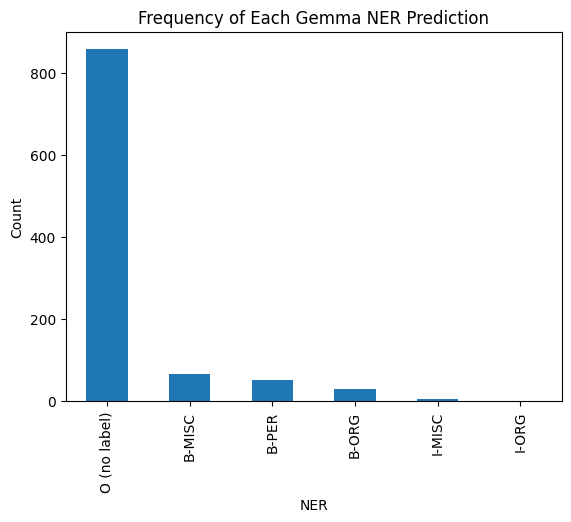

In [153]:
#Frequency of predictions
df['gemma_ner'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Gemma NER Prediction')
plt.xlabel('NER')
plt.ylabel('Count')
plt.show()

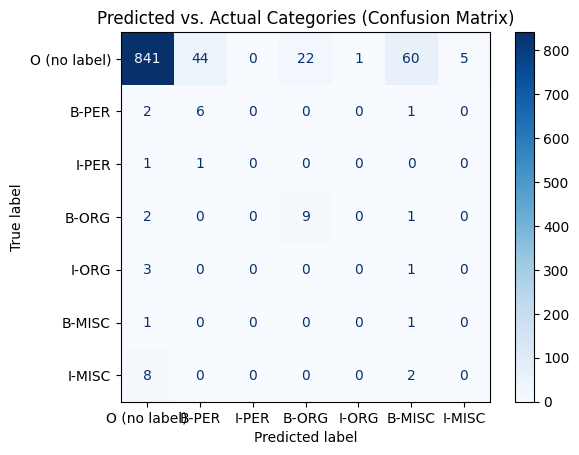

In [154]:
#Confusion matrix
cm = confusion_matrix(df['ner'], df['gemma_ner'], labels=["O (no label)", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-MISC", "I-MISC"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["O (no label)", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-MISC", "I-MISC"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [155]:
#Macro F1
macro_f1 = f1_score(df["ner"], df["gemma_ner"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.1958



In [156]:
#F1 Per Class
f1_per_class = f1_score(df["ner"], df["gemma_ner"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.         0.02898551 0.41860465 0.2        0.         0.
 0.         0.9186237 ]



In [157]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["ner"], df["gemma_ner"]))

Classification Report:
              precision    recall  f1-score   support

       B-LOC       0.00      0.00      0.00         1
      B-MISC       0.01      0.50      0.03         2
       B-ORG       0.29      0.75      0.42        12
       B-PER       0.12      0.67      0.20         9
      I-MISC       0.00      0.00      0.00        10
       I-ORG       0.00      0.00      0.00         4
       I-PER       0.00      0.00      0.00         2
O (no label)       0.98      0.86      0.92       973

    accuracy                           0.85      1013
   macro avg       0.18      0.35      0.20      1013
weighted avg       0.95      0.85      0.89      1013



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [160]:
mismatched_rows = df[df['ner'] != df['gemma_ner']]

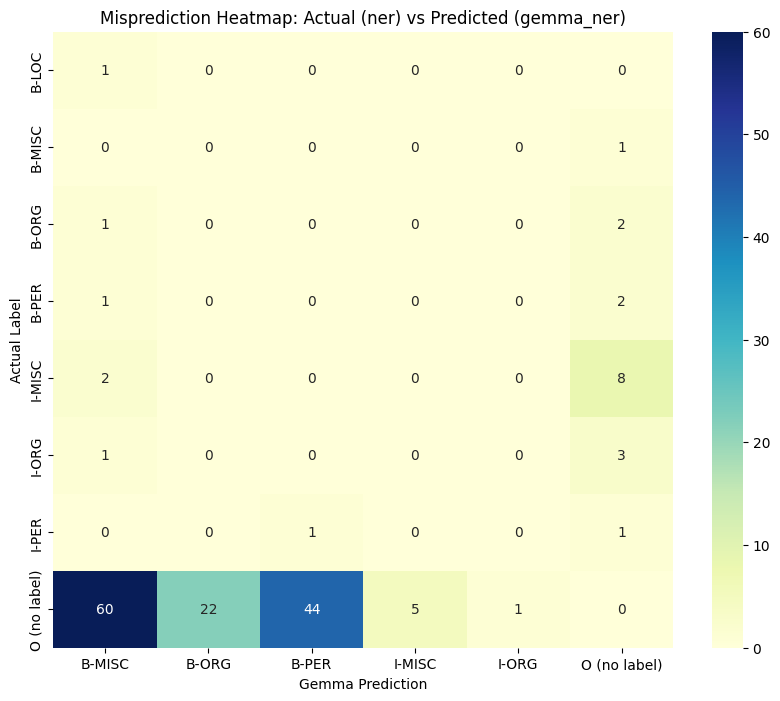

In [161]:
#Mismatched rows CM
confusion_matrix = pd.crosstab(mismatched_rows['ner'], mismatched_rows['gemma_ner'])
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (ner) vs Predicted (gemma_ner)')
plt.ylabel('Actual Label')
plt.xlabel('Gemma Prediction')
plt.show()

In [162]:
mismatched_rows

,Unnamed: 0.1,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gemma_ner
2,2,2,post_0001,1,2,hocamızın,TR,NONE,O (no label),B-PER
7,7,7,post_0001,1,7,tanımıyla,TR,NONE,O (no label),B-PER
8,8,8,post_0001,1,8,university,EN,NONE,O (no label),B-ORG
11,11,11,post_0001,1,11,place,EN,NONE,O (no label),B-MISC
18,18,18,post_0001,1,18,and,EN,NONE,O (no label),B-PER
...,...,...,...,...,...,...,...,...,...,...
1058,1058,1058,post_0039,1,0,personalised,EN,NONE,O (no label),B-MISC
1059,1059,1059,post_0039,1,1,search,EN,NONE,O (no label),B-ORG
1074,1074,1074,post_0039,4,4,kenarda,TR,NONE,O (no label),B-PER
1088,1088,1088,post_0039,5,3,james,OTHER,NONE,I-PER,B-PER
